# Simple Visualizations: Autonomous Radar Telemetry Preprocessing

The full preprocessing runs on all columns, but the graphs only show a few key features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('autonomous_radar_telemetry_50k.csv')
df_clean = df.copy()
print(f"Original Dataset Shape: {df.shape}")

Original Dataset Shape: (50000, 20)


## Step A: Structural Cleaning

In [3]:
missing_per_col = df_clean.isnull().sum()
duplicate_count = df_clean.duplicated().sum()
rows_before = len(df_clean)

df_clean.drop_duplicates(inplace=True)
rows_after = len(df_clean)

print(f"Total Missing Values: {missing_per_col.sum()}")
print(f"Duplicate Records Removed: {duplicate_count}")

Total Missing Values: 0
Duplicate Records Removed: 0


## Step B: Outlier Treatment (IQR Capping)

In [5]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
excluded_cols = ['sensor_degraded_flag']
target_num_cols = [c for c in num_cols if c not in excluded_cols]

df_before_cap = df_clean.copy()
outlier_summary = {}

for col in target_num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_summary[col] = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

print({k: v for k, v in outlier_summary.items() if v > 0})

{'radar_frequency_ghz': 328, 'tx_power_dbm': 374, 'rx_gain_db': 328, 'doppler_velocity_mps': 340, 'radar_rcs_dbm2': 373, 'sensor_temp_c': 331, 'mcu_voltage_v': 350, 'packet_latency_ms': 378, 'precipitation_rate_mmh': 2509}


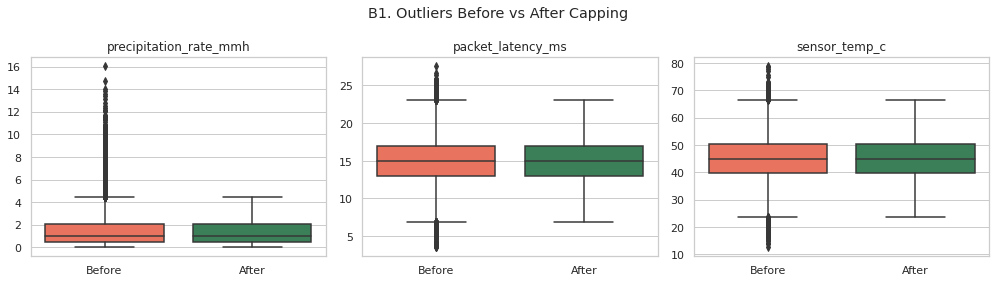

In [6]:
# B1: Boxplot before vs after capping for 3 key features
b_features = ['precipitation_rate_mmh', 'packet_latency_ms', 'sensor_temp_c']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, b_features):
    data = pd.DataFrame({'Before': df_before_cap[col], 'After': df_clean[col]})
    sns.boxplot(data=data, ax=ax, palette=['tomato', 'seagreen'])
    ax.set_title(col)
fig.suptitle("B1. Outliers Before vs After Capping")
plt.tight_layout()
plt.show()

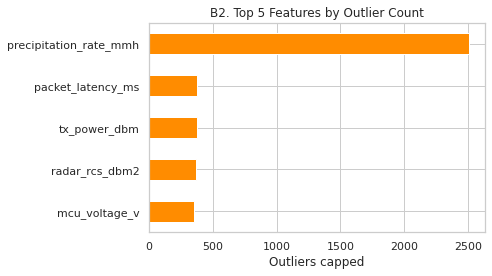

In [7]:
# B2: Top 5 features by number of outliers
top5 = pd.Series(outlier_summary).sort_values(ascending=False).head(5)

plt.figure(figsize=(7, 4))
top5.sort_values().plot(kind='barh', color='darkorange')
plt.title("B2. Top 5 Features by Outlier Count")
plt.xlabel("Outliers capped")
plt.tight_layout()
plt.show()

## Step C: Log Transformation of Skewed Features

In [8]:
skewed_features = ['precipitation_rate_mmh', 'packet_latency_ms', 'ambient_lux']
for col in skewed_features:
    if col in df_clean.columns:
        df_clean[f'log_{col}'] = np.log1p(df_clean[col])
        print(f"Log transformation applied to: {col}")

Log transformation applied to: precipitation_rate_mmh
Log transformation applied to: packet_latency_ms
Log transformation applied to: ambient_lux


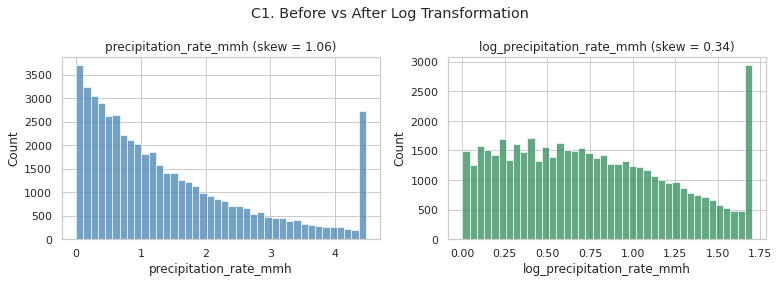

In [9]:
# C1: Histogram before vs after log1p
# precipitation_rate_mmh is the only clearly right-skewed feature in this dataset
col = 'precipitation_rate_mmh'

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_clean[col], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title(f"{col} (skew = {df_clean[col].skew():.2f})")
sns.histplot(df_clean[f'log_{col}'], bins=40, ax=axes[1], color='seagreen')
axes[1].set_title(f"log_{col} (skew = {df_clean[f'log_{col}'].skew():.2f})")
fig.suptitle("C1. Before vs After Log Transformation")
plt.tight_layout()
plt.show()

## Step D: Normalization and Standardization

In [10]:
scale_features = [
    'vehicle_speed_kmh', 'tx_power_dbm', 'snr_db',
    'target_range_meters', 'sensor_temp_c', 'mcu_voltage_v'
]

scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

df_clean[[f'{col}_norm' for col in scale_features]] = scaler_minmax.fit_transform(df_clean[scale_features])
df_clean[[f'{col}_std' for col in scale_features]] = scaler_std.fit_transform(df_clean[scale_features])
print("Scaling completed.")

Scaling completed.


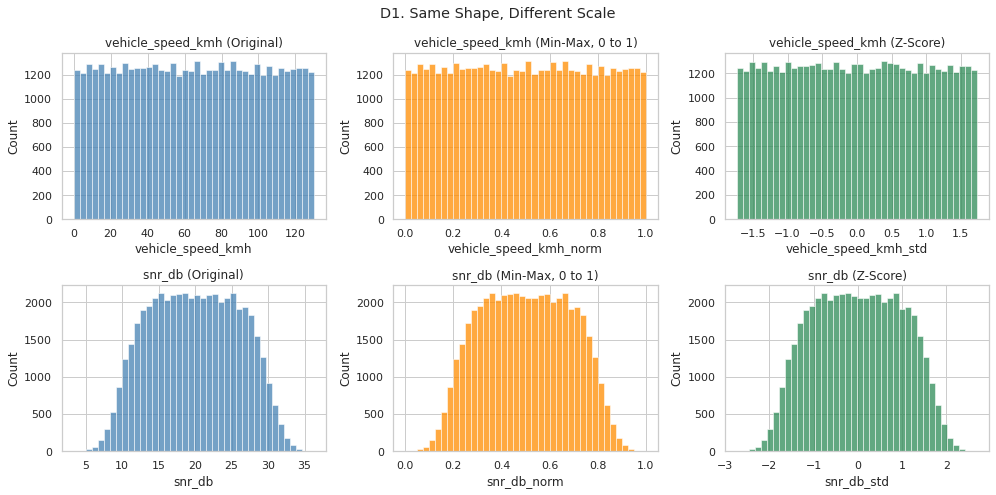

In [11]:
# D1: Original vs Min-Max vs Z-Score for 2 features
d_features = ['vehicle_speed_kmh', 'snr_db']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(d_features):
    sns.histplot(df_clean[col], bins=40, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f"{col} (Original)")
    sns.histplot(df_clean[f'{col}_norm'], bins=40, ax=axes[i, 1], color='darkorange')
    axes[i, 1].set_title(f"{col} (Min-Max, 0 to 1)")
    sns.histplot(df_clean[f'{col}_std'], bins=40, ax=axes[i, 2], color='seagreen')
    axes[i, 2].set_title(f"{col} (Z-Score)")
fig.suptitle("D1. Same Shape, Different Scale")
plt.tight_layout()
plt.show()

## Step E: Feature Engineering

In [12]:
df_clean['power_to_voltage_ratio'] = df_clean['tx_power_dbm'] / df_clean['mcu_voltage_v']

df_clean['thermal_status'] = pd.cut(
    df_clean['sensor_temp_c'],
    bins=[-np.inf, 40, 60, np.inf],
    labels=['Normal', 'High', 'Critical']
)

df_clean['snr_category'] = pd.cut(
    df_clean['snr_db'],
    bins=[-np.inf, 10, 20, np.inf],
    labels=['Low', 'Medium', 'High']
)

df_clean['range_speed_interaction'] = df_clean['target_range_meters'] * df_clean['vehicle_speed_kmh']
print("Engineered features added.")

Engineered features added.


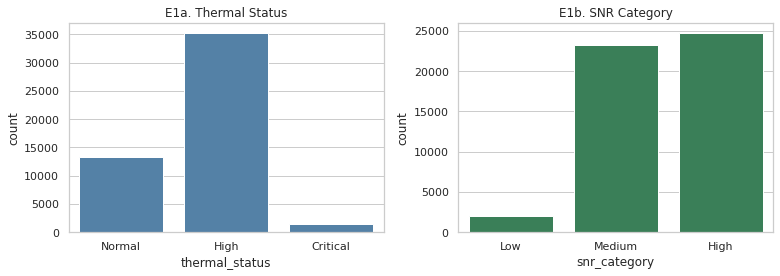

In [13]:
# E1: Counts of the two categorical features
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x='thermal_status', data=df_clean, order=['Normal', 'High', 'Critical'], ax=axes[0], color='steelblue')
axes[0].set_title("E1a. Thermal Status")

sns.countplot(x='snr_category', data=df_clean, order=['Low', 'Medium', 'High'], ax=axes[1], color='seagreen')
axes[1].set_title("E1b. SNR Category")

plt.tight_layout()
plt.show()

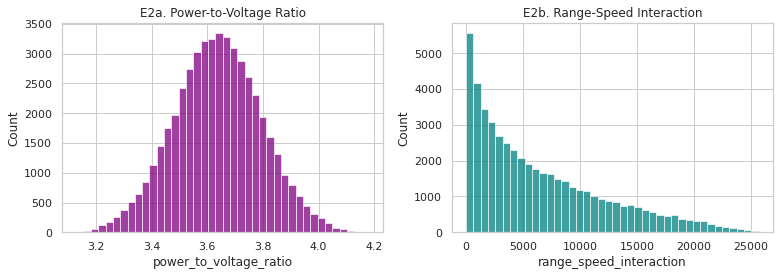

In [14]:
# E2: Distribution of the engineered numeric features
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(df_clean['power_to_voltage_ratio'], bins=40, ax=axes[0], color='purple')
axes[0].set_title("E2a. Power-to-Voltage Ratio")

sns.histplot(df_clean['range_speed_interaction'], bins=40, ax=axes[1], color='teal')
axes[1].set_title("E2b. Range-Speed Interaction")

plt.tight_layout()
plt.show()

## Step F: Final Verification

In [15]:
print(f"Final Preprocessed Dataset Shape: {df_clean.shape}")
print(f"Missing Values Check: {df_clean.isnull().sum().sum()}")
print(f"Duplicate Records Check: {df_clean.duplicated().sum()}")

Final Preprocessed Dataset Shape: (50000, 39)
Missing Values Check: 0
Duplicate Records Check: 0


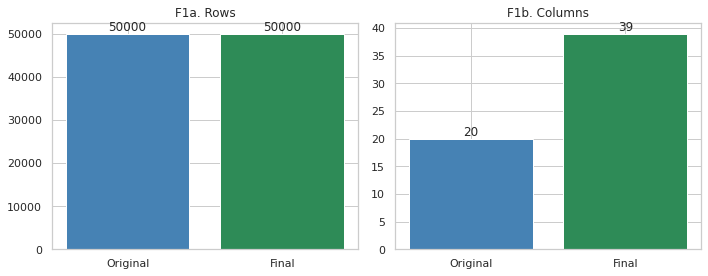

In [16]:
# F1: Rows and columns, original vs final
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bars = axes[0].bar(["Original", "Final"], [df.shape[0], df_clean.shape[0]], color=["steelblue", "seagreen"])
axes[0].bar_label(bars)
axes[0].set_title("F1a. Rows")

bars = axes[1].bar(["Original", "Final"], [df.shape[1], df_clean.shape[1]], color=["steelblue", "seagreen"])
axes[1].bar_label(bars)
axes[1].set_title("F1b. Columns")

plt.tight_layout()
plt.show()

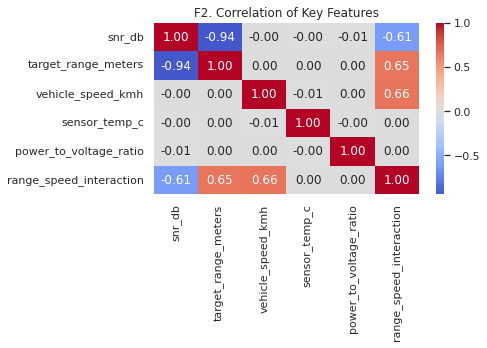

In [17]:
# F2: Correlation between a few key features
key_cols = ['snr_db', 'target_range_meters', 'vehicle_speed_kmh', 'sensor_temp_c',
            'power_to_voltage_ratio', 'range_speed_interaction']

plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[key_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("F2. Correlation of Key Features")
plt.tight_layout()
plt.show()